In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [87]:
# A0A267FLT7_IPR045860_1_40-116 <UniProt_ID>_<InterProID>_<???>_<start_domain>_<end_domain>
df = pd.read_csv("../../data/raw/data_for_tree/clusters.tsv", sep='\t', header=None, names=["rep", "member"])
df["protein_id"] = np.where(
    df["member"].str.contains("Centipede", case=False, na=False),
    df["member"],
    df["member"].str.split("_").str[0]
)
df

,rep,member,protein_id
0,A0A267FLT7_IPR045860_1_40-116,A0A267FLT7_IPR045860_1_40-116,A0A267FLT7
1,A0A267FLT7_IPR045860_1_40-116,A0A1I8GI43_IPR045860_1_116-193,A0A1I8GI43
2,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B5M3Y7
3,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B5R573_IPR045860_1_54-113,A0A3B5R573
4,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B3XDD9_IPR045860_1_53-121,A0A3B3XDD9
...,...,...,...
58182,A0A210QMG5_IPR045860_1_21-111,A0A210PIL5_IPR016054_1_31-126,A0A210PIL5
58183,A0A210QMG5_IPR045860_1_21-111,A0A8W8KZL2_IPR045860_2_19-109,A0A8W8KZL2
58184,A0A210QMG5_IPR045860_1_21-111,K1R0S6_IPR045860_1_9-93,K1R0S6
58185,A0A210QMG5_IPR045860_1_21-111,A0A8W8KWF8_IPR045860_2_23-106,A0A8W8KWF8


In [88]:
rep_to_cluster = {rep: i for i, rep in enumerate(sorted(df["rep"].unique()))}
df["cluster_id"] = df["rep"].map(rep_to_cluster)
df

,rep,member,protein_id,cluster_id
0,A0A267FLT7_IPR045860_1_40-116,A0A267FLT7_IPR045860_1_40-116,A0A267FLT7,252
1,A0A267FLT7_IPR045860_1_40-116,A0A1I8GI43_IPR045860_1_116-193,A0A1I8GI43,252
2,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B5M3Y7,317
3,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B5R573_IPR045860_1_54-113,A0A3B5R573,317
4,A0A3B5M3Y7_IPR045860_1_54-113,A0A3B3XDD9_IPR045860_1_53-121,A0A3B3XDD9,317
...,...,...,...,...
58182,A0A210QMG5_IPR045860_1_21-111,A0A210PIL5_IPR016054_1_31-126,A0A210PIL5,226
58183,A0A210QMG5_IPR045860_1_21-111,A0A8W8KZL2_IPR045860_2_19-109,A0A8W8KZL2,226
58184,A0A210QMG5_IPR045860_1_21-111,K1R0S6_IPR045860_1_9-93,K1R0S6,226
58185,A0A210QMG5_IPR045860_1_21-111,A0A8W8KWF8_IPR045860_2_23-106,A0A8W8KWF8,226


In [89]:
# Count how many members each cluster has
df["cluster_id"].value_counts()

cluster_id
1700    3240
225     2600
556     2388
84      2048
1076    1888
        ... 
583        1
1470       1
1373       1
1365       1
976        1
Name: count, Length: 1747, dtype: int64

In [71]:
metadata = pd.read_csv("../../data/raw/data_for_tree/interpro/3FTx_related.csv")
metadata

,protein_id,protein_name,tax_id,scientific_name,sequence_length,domain_start,domain_end,signature_name,interpro_domain_name
0,A0A8C6DNS2,Snake toxin/toxin-like domain-containing protein,68415,Moschus moschiferus,141,39,116,IPR035076,Snake toxin/toxin-like
1,A0A8C6DNS2,Snake toxin/toxin-like domain-containing protein,68415,Moschus moschiferus,141,32,118,IPR045860,Snake toxin-like superfamily
2,A0A8C6DNS2,Snake toxin/toxin-like domain-containing protein,68415,Moschus moschiferus,141,21,133,IPR051110,Ly-6/neurotoxin-like and GPI-anchored
3,Q0GB18,Plethodontid modulating factor,263671,Plethodon shermani,82,20,82,IPR045860,Snake toxin-like superfamily
4,K7FHR4,UPAR/Ly6 domain-containing protein,13735,Pelodiscus sinensis,127,21,112,IPR016054,Ly-6 antigen/uPA receptor-like
...,...,...,...,...,...,...,...,...,...
49348,A0A7N9CPV3,Snake toxin/toxin-like domain-containing protein,9541,Macaca fascicularis,165,41,122,IPR045860,Snake toxin-like superfamily
49349,A0A7N9CPV3,Snake toxin/toxin-like domain-containing protein,9541,Macaca fascicularis,165,1,165,IPR052874,Sperm-binding zona pellucida regulatory protein
49350,A0AAN8NYN3,Protein sleepless,468196,Polyplax serrata,143,22,116,IPR031424,UPAR/Ly6 domain-containing protein Quiver-like
49351,A0AAN8NYN3,Protein sleepless,468196,Polyplax serrata,143,21,117,IPR045860,Snake toxin-like superfamily


In [72]:
# Initialize an empty list to store results
merged_list = []

for _, row in df.iterrows():
    member = row['member']
    # Find all metadata rows where identifier is substring of member
    matches = metadata[metadata['protein_id'].apply(lambda x: x in member)].copy()
    if matches.empty:
        # If no match, keep the df row with NaNs for metadata columns
        merged_list.append({**row})
    else:
        for _, m_row in matches.iterrows():
            merged_list.append({**row, **m_row.to_dict()})

df_merged = pd.DataFrame(merged_list)

# Reorder columns: member, cluster_id first
cols = ['member','cluster_id'] + [c for c in df_merged.columns if c not in ['member','cluster_id']]
df_merged = df_merged[cols]

In [73]:
df_merged["cluster_id"].value_counts()

cluster_id
556     4415
1700    3266
1520    3166
1695    2976
225     2620
        ... 
95         1
1497       1
1464       1
1595       1
553        1
Name: count, Length: 1747, dtype: int64

In [74]:
df_merged

,member,cluster_id,protein_id,protein_name,tax_id,scientific_name,sequence_length,domain_start,domain_end,signature_name,interpro_domain_name
0,A0A267FLT7_IPR045860_1_40-116,252,A0A267FLT7,Uncharacterized protein,282301.0,Macrostomum lignano,161.0,40.0,116.0,IPR045860,Snake toxin-like superfamily
1,A0A1I8GI43_IPR045860_1_116-193,252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A0A3B5M3Y7_IPR045860_1_54-113,317,A0A3B5M3Y7,UPAR/Ly6 domain-containing protein,32473.0,Xiphophorus couchianus,136.0,4.0,50.0,IPR045860,Snake toxin-like superfamily
3,A0A3B5M3Y7_IPR045860_1_54-113,317,A0A3B5M3Y7,UPAR/Ly6 domain-containing protein,32473.0,Xiphophorus couchianus,136.0,54.0,113.0,IPR045860,Snake toxin-like superfamily
4,A0A3B5M3Y7_IPR045860_1_54-113,317,A0A3B5M3Y7,UPAR/Ly6 domain-containing protein,32473.0,Xiphophorus couchianus,136.0,10.0,87.0,IPR050918,CNF-like Phospholipase A2 Inhibitor
...,...,...,...,...,...,...,...,...,...,...,...
88442,A0A210PIL5_IPR016054_1_31-126,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88443,A0A8W8KZL2_IPR045860_2_19-109,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88444,K1R0S6_IPR045860_1_9-93,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88445,A0A8W8KWF8_IPR045860_2_23-106,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


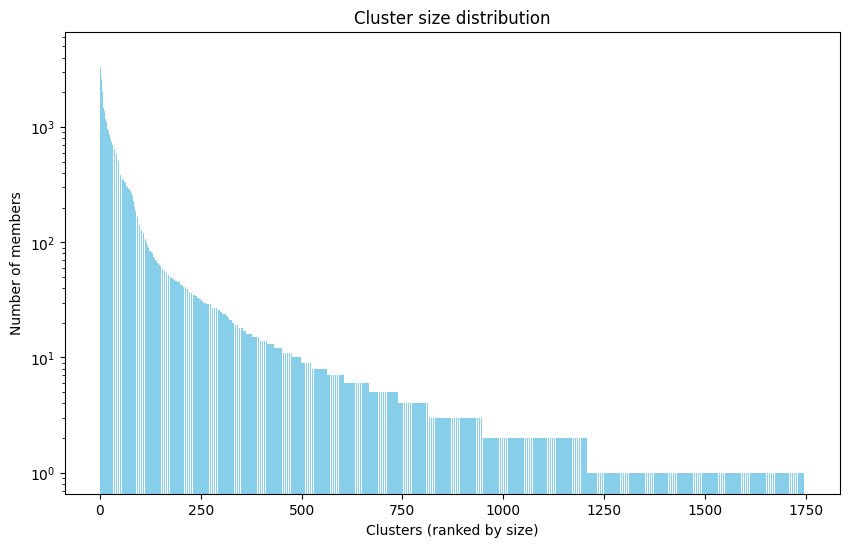

In [90]:
# count members per cluster and sort descending
cluster_sizes = df_merged.groupby("cluster_id")["member"].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(range(len(cluster_sizes)), cluster_sizes.values, color='skyblue')
plt.xlabel("Clusters (ranked by size)")
plt.ylabel("Number of members")
plt.yscale('log')
plt.title("Cluster size distribution")
plt.show()

In [30]:
# (((xref:interpro-IPR016054 OR xref:interpro-IPR026110 OR xref:interpro-IPR026524 OR xref:interpro-IPR031424 OR xref:interpro-IPR038773 OR xref:interpro-IPR039457 OR xref:interpro-IPR039237 OR xref:interpro-IPR042339 OR xref:interpro-IPR051445 OR xref:interpro-IPR035076 OR xref:interpro-IPR003571 OR xref:interpro-IPR045860) AND fragment:false) OR (accession:I6R1R5 OR accession:P0DPX5 OR accession:P0DPX9 OR accession:P0DPY0 OR accession:P0DPY1 OR accession:P0DPX7 OR accession:P0DPX8 OR accession:P0DPX6 OR accession:P0DPU8)) AND (taxonomy_id:33208)